# New version, using the .parquet exports
instead of synchronizing the complete postgresql database all the time, i can export PARAM and METRIC .parquet files per group_id and only synchronize/copy what i need.

In [2]:
import sys
import os
project_root = os.path.abspath('..')          # one level up from notebooks directory
if project_root not in sys.path:
    sys.path.append(project_root)

import pandas as pd
import numpy as np

In [3]:
tag = '2026-03-19_16-20-45'
PARAMS = pd.read_parquet(f"../data/experiments/exports/['{tag}']-params.parquet")
METRICS = pd.read_parquet(f"../data/experiments/exports/['{tag}']-metrics.parquet")

In [4]:
from key_mapping import key_mapping
from data_preparation import add_grouped_mean_columns, get_multi_carrier_metrics

METRICS_WIDE = METRICS.pivot(columns='key', index=['run_uuid', 'step'], values='value').reset_index()
single_step_metrics = [col for col in METRICS_WIDE.columns if pd.isna(METRICS_WIDE[METRICS_WIDE['step'] > 0][col]).all()]
SS_METRICS = METRICS_WIDE[METRICS_WIDE['step'] == 0][['run_uuid'] + single_step_metrics]
SS_MERGED = pd.merge(PARAMS, SS_METRICS, on='run_uuid')
add_grouped_mean_columns(SS_MERGED, inplace=True)

# single step, multi-carrier metrics
SS_MC_METRICS = get_multi_carrier_metrics(SS_METRICS)
SS_MC_MERGED = pd.merge(PARAMS, SS_MC_METRICS, on='run_uuid')

# Multi-step metrics
multi_step_metrics = [col for col in METRICS_WIDE.columns if col not in single_step_metrics]
MS_METRICS = METRICS_WIDE[multi_step_metrics]
MS_METRICS.update(MS_METRICS.groupby('run_uuid').ffill())  # forward fill the multi-step metrics that might have gaps
MS_METRICS = MS_METRICS.replace(np.inf, np.nan)
add_grouped_mean_columns(MS_METRICS, inplace=True)
MS_MERGED = pd.merge(PARAMS, MS_METRICS, on='run_uuid')

# to wide format
SS_MC_MERGED_WIDE = SS_MC_MERGED.pivot(columns='key', values='value', index=PARAMS.columns.to_list() + ['carrier']).reset_index()
SS_MC_MERGED_WIDE = SS_MC_MERGED_WIDE.rename(columns=key_mapping)

updating value_mapping...
Identified groups: ['my_MinWBMP', 'my_convex_hull_jaccard_distance', 'my_hausdorff_distance', 'my_modified_hausdorff_distance', 'my_tsp_hull_jaccard_distance', 'my_tsp_obj_val_diff', 'target_opt_final']
Identified groups: ['target', 'target_opt']


In [5]:
non_unique_params: pd.DataFrame = PARAMS.loc[:, PARAMS.nunique() != 1]
non_unique_params = non_unique_params.drop(columns=[
    'run_uuid',
    'name_x',
    'source_type',
    'source_name',
    'entry_point_name',
    'user_id',
    'status',
    'start_time',
    'end_time',
    'source_version',
    'lifecycle_stage_x',
    'artifact_uri',
    'experiment_id',
    'deleted_time',
    'name_y',
    'artifact_location',
    'lifecycle_stage_y',
    'creation_time',
    'last_update_time',
    'group_id',
    'instance_id',
    'mlflow.runName',
    'mlflow.source.git.commit',
    'mlflow.source.name',
    'mlflow.source.type',
    'mlflow.user',
    'mlflow.loggedArtifacts',
],
    errors='ignore',
    inplace=False)
print("List of non-unique parameters:")
list(non_unique_params.columns)

List of non-unique parameters:


['Optimizer', 'Optimizer Type', 'Cluster std', '# clusters', 'data__run']

## Plots

Optimizer         # clusters  data__num_requests_per_carrier  LOC  
GN_DIRECT_L_RAND  3           16                              False    600
                  None        16                              False    600
LN_NELDERMEAD     3           16                              False    600
                  None        16                              False    600
Name: target_opt_final, dtype: int64


/home/steffen/miniforge3/envs/CACT/lib/python3.10/site-packages/plotnine/guides/guides.py:211: PlotnineWarning: Cannot generate legend for the 'color' aesthetic. Make sure you have mapped a variable to it


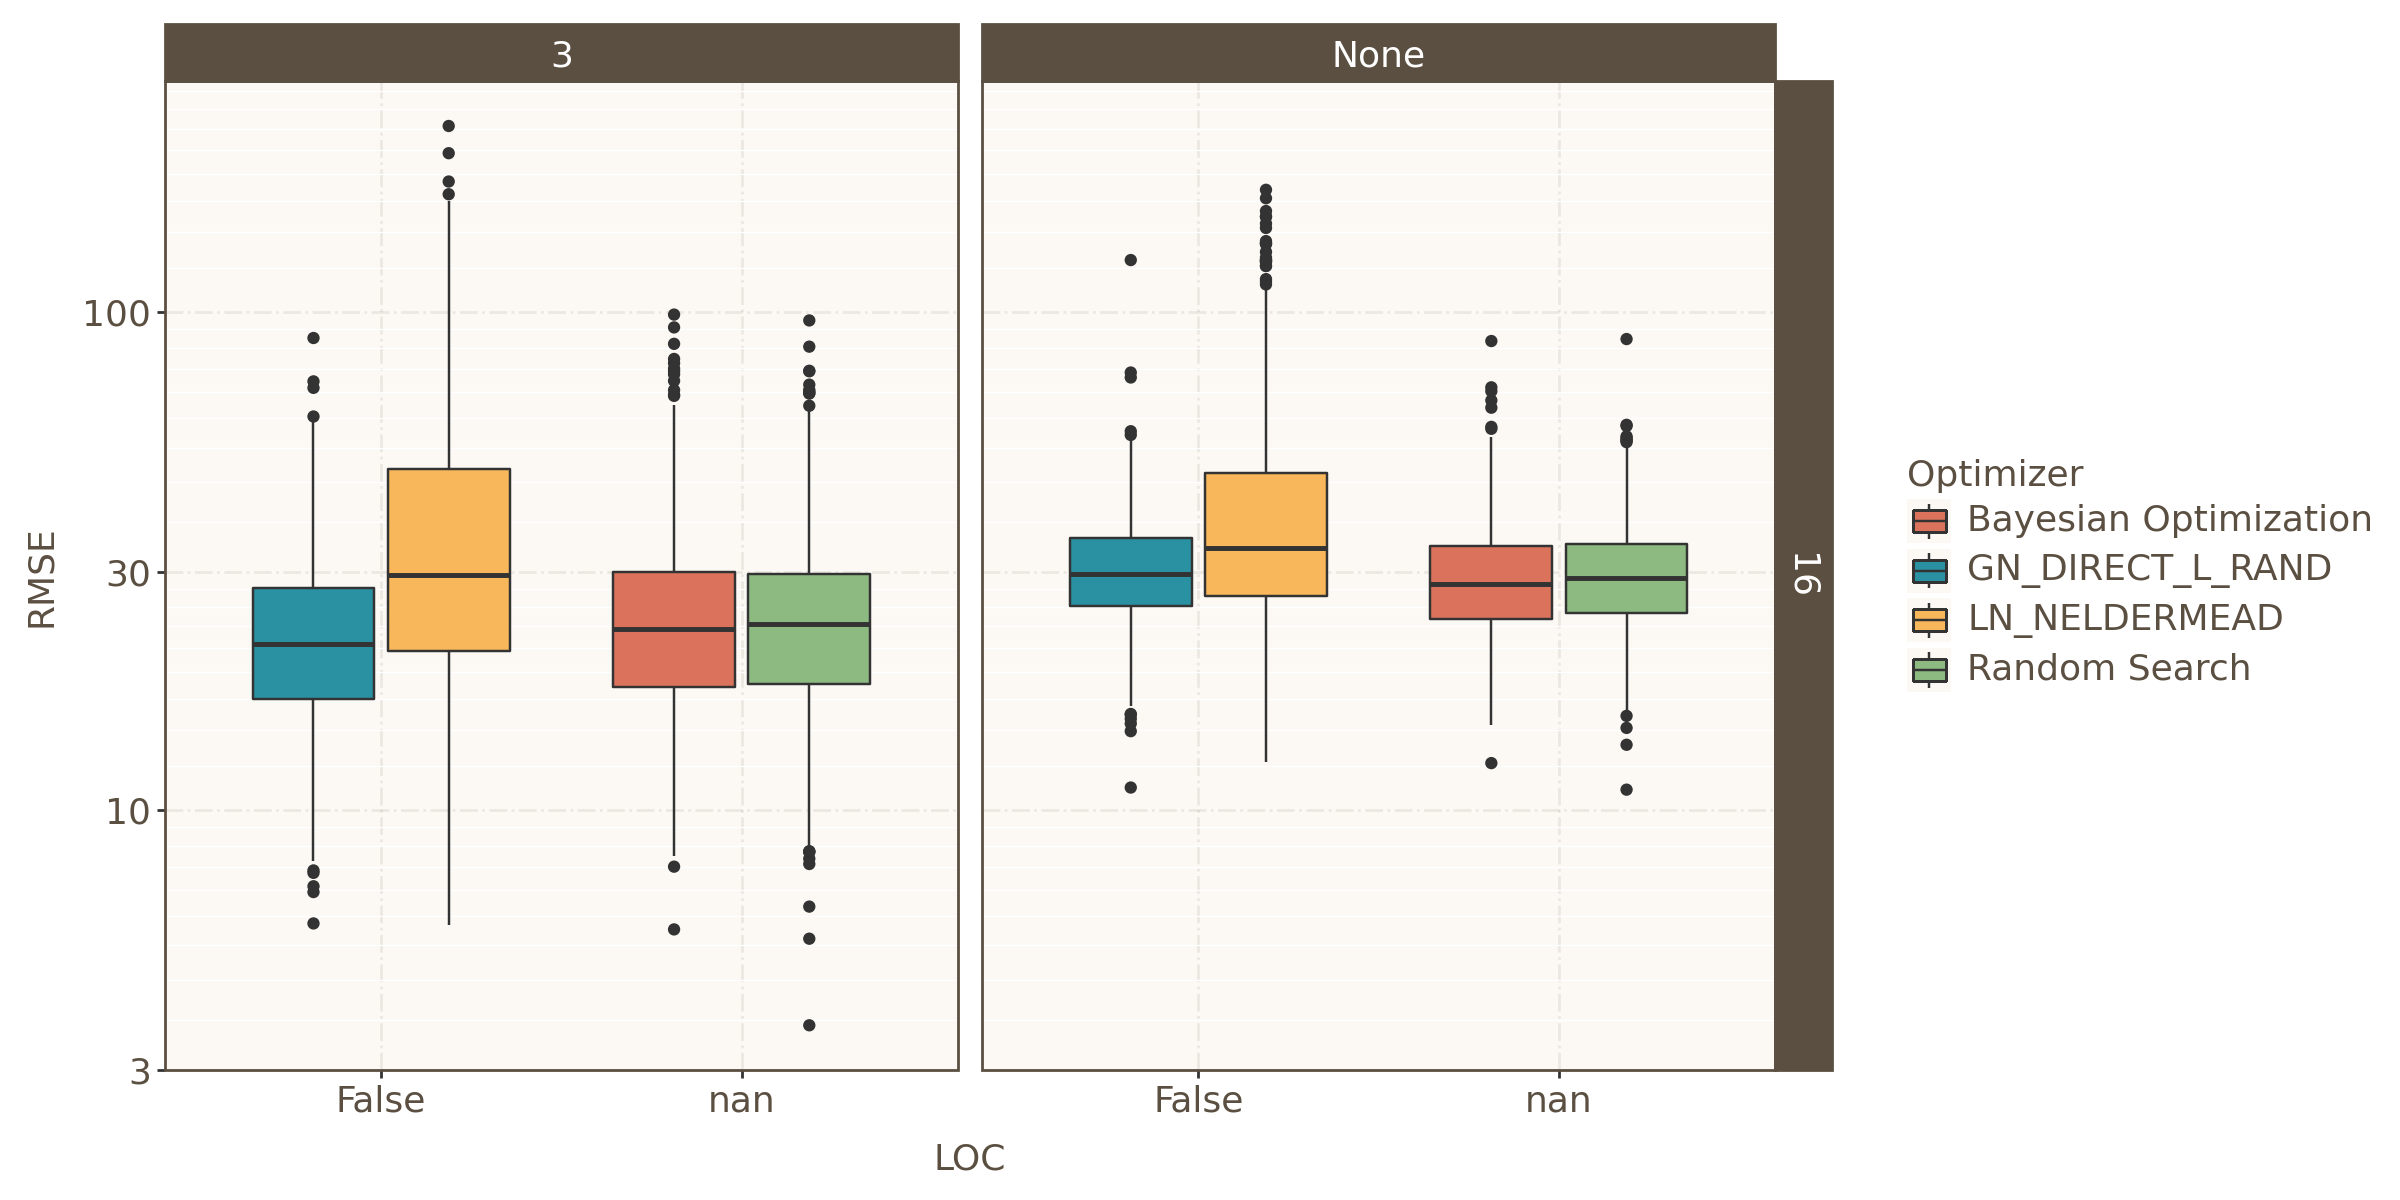

In [8]:
import plotnine as p9
from my_theming import my_p9_theme, my_scale_color_and_fill


x = "LOC"
y = "target_opt_final"
fill = "Optimizer"
cols = "# clusters"
rows = "data__num_requests_per_carrier"
linetype = "LOC"
ylab = SS_MC_MERGED_WIDE["Error Function"][0] if y == "target_opt_final" else y
p = (
    p9.ggplot(SS_MC_MERGED_WIDE,
            p9.aes(x=x,
                y=y,
                fill=fill,
                #  linetype=linetype
        ))
    + p9.geom_boxplot()
    # + geom_jitter(width=0.3, alpha=0.2)
    + p9.facet_grid(
        cols=cols,
        rows=rows,
        # labeller="label_both"
    )
    + my_p9_theme
    + p9.theme(
        figure_size=(12, 6),
        # axis_text_x=p9.element_blank(),
        # axis_ticks_x=p9.element_blank(),
        # axis_title_x=p9.element_blank(),
    )
    + my_scale_color_and_fill
    + p9.scale_y_log10()
    + p9.labs(y=ylab)
)
t = SS_MC_MERGED_WIDE.groupby([fill, cols, rows, linetype])[y].count()
print(t)
# p.save(fig_dir + f'/{y}_{selected_group_ids}.pdf')
p